## Please, before you start thi notebook

Please install these components in the versions listed below. Unfortunately, the versions bundled with WESL can cause incompatibilities because they are more up to date.

In [1]:
# %pip install --upgrade --force-reinstall \
#     openmdao==3.40.0 \
#     numpy==2.3.2 \
#     matplotlib==3.10.6 \
#     ipympl==0.10.0

In [2]:
import openmdao, numpy, matplotlib, ipympl

print("openmdao:", openmdao.__version__)
print("numpy:", numpy.__version__)
print("matplotlib:", matplotlib.__version__)
print("ipympl:", ipympl.__version__)

openmdao: 3.40.0
numpy: 2.3.2
matplotlib: 3.10.6
ipympl: 0.10.0


# Wind Farm Layout Optimization

This notebook builds and runs an optimization workflow for a wind farm layout problem.

The goal is simple:

- place turbines inside the farm boundary,
- keep them far enough apart,
- and maximize energy production while respecting the constraints.

We compare two optimization drivers:

- **SGD** as a baseline,
- **NCG** as the custom nonlinear conjugate gradient driver.

The notebook is written to behave like a small digital lab: each block introduces one part of the problem, then runs it, then inspects what happened.

## Problem Overview

This is a layout optimization problem.

Each turbine position is a design variable, so the optimizer is free to move the layout in search of better energy production. At the same time, the solution must remain physically valid:

- turbines cannot overlap,
- turbines must stay inside the boundary,
- and the final layout should not violate the spacing rules.

The objective is not only to get a high AEP value, but to do so with a clean feasible layout.

## What We Are Testing

The main idea here is to compare a standard optimization strategy against a modified one.

- **SGD** gives us a reference point, approach from DTU.
- **NCG** is the method being developed and tested.

This makes the notebook useful for two reasons:

1. it shows whether the custom driver is working,
2. it shows whether it improves the optimization behavior in practice.

So this is about understanding how the optimizer behaves step by step.

## Imports and Setup

This notebook relies on a modular optimization pipeline.

The imports below bring together:
- the OpenMDAO framework,
- the project-specific AEP and constraint components,
- the custom optimization drivers,
- and the plotting / recording utilities used to inspect the run.

The goal is to keep the notebook structured and easy to trace from start to finish.

In [3]:
import openmdao.api as om
import numpy as np
from pathlib import Path
import os
import sys
import matplotlib
import matplotlib.pyplot as plt

if ".." not in sys.path:
    sys.path.insert(0, "..")

from simplerecorder import SimpleRecorder
from mysite import get_setup_params
from aep import AEPCompStochastic, AEPComp
from constraints import SpacingConstraintComp, BoundaryConstraintComp
from aggregator import ConstraintAggregator
from penalty import PenaltyObjectiveComp, FinalRMSViol
from simpleplot import LayoutVisualizer, PlotComp, plot_convergence_comparison
from Drivers import NCG, SGD

Loaded: default.csv (1 turbines)
Boundary: 0m x 0m


/opt/anaconda3/envs/Test_jun_23/lib/python3.11/site-packages/py_wake/deficit_models/gaussian.py:124: UserWarning: The BastankhahGaussian model is not representative of the setup used in the literature. For this, use py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014 instead
  DeprecatedModel.__init__(self, 'py_wake.literature.gaussian_models.Bastankhah_PorteAgel_2014')


## 1. Case Loading and Parameter Initialization

The initialization phase dynamically loads site-specific data, structural properties, and baseline configurations without hard-coded limits.

* **Data Input:** The `get_setup_params(csv_filename)` function parses input CSV files from the `Optimizers_Bruno/Designs/` directory via `mysite.py`.
* **Wake Models:** The pipeline integrates with `Py-Wake` utilizing the `LillgrundSite` environment definition, `HornsrevV80` turbine characteristics, and the `BastankhahGaussian` wake deficit model.
* **Geometric Limits:** Minimum inter-turbine spatial requirements are computed based on the rotor diameter $D$:

$$\text{min\_spacing\_m} = \text{min\_spacing\_d} \times D = 2D$$


---

## 2. Baseline Layout Check

Before initializing the OpenMDAO driver, a deterministic baseline calculation evaluates the initial $(x_{\text{init}}, y_{\text{init}})$ spatial vectors:

$$\text{AEP}_0 = \sum \text{wfm}(x_{\text{init}}, y_{\text{init}}).\text{aep}()$$

This provides a baseline annual energy production benchmark and ensures the wake model instantiation is mathematically sound before gradient evaluation begins.

---

## 3. Driver choice

The architecture evaluates two optimization schemes via a functional mapping strategy:
* `0` (or `False`): Maps to **SGD** (Stochastic Gradient Descent)
* `1` (or `True`): Maps to **NCG** (Non-linear Conjugate Gradient)

```python
driver_map = {0: SGD, 1: NCG}
DriverClass = driver_map[driver]
```

## 4. Results in the recorders

To track long-term convergence histories rather than just final local minima, a custom `SimpleRecorder` interfaces directly with OpenMDAO's internal execution loops. It serializes spatial configurations, current objective values, constraint violations, and active iteration states into distinct subdirectories: `Results/sgd/` or `Results/ncg/`.

## 5. Explicit Component and Constraints 

OpenMDAO handles calculations through custom `ExplicitComponent` objects. To enable analytical gradient-based optimization, every component declares its partial derivatives analytically using sparse or block array representations.

### Spacing Constraint Component [`SpacingConstraintComp`](../constraints.py)
This component evaluates the pairwise Euclidean distance for all unique combinations of turbines to avoid aerodynamic shadowing and physical overlap. For $n$ turbines, it tracks a constraint vector $g_{\text{spacing}}$ of size $m = \frac{n(n-1)}{2}$.

* **Mathematical Convention:** $g_{k} \le 0$ indicates a feasible layout, while $g_{k} > 0$ denotes a proximity violation. 
* **Forward Sweep ($g_k$ for a pair $i, j$):**

$$d_{ij} = \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2 + \epsilon}$$

$$g_k = \begin{cases} 
0.0 & \text{if } d_{\text{min}} - d_{ij} < 0 \\ 
d_{\text{min}} - d_{ij} & \text{if } d_{\text{min}} - d_{ij} \ge 0 
\end{cases}$$

* **Analytical Derivatives:** Partials are only evaluated for active violations ($g_k > 0$). The Jacobian entries are derived via the chain rule, utilizing an explicit negative mapping convention (`-jac_x`, `-jac_y`) inside OpenMDAO:

$$\frac{\partial g_k}{\partial x_i} = -\frac{x_i - x_j}{d_{ij}}, \quad \frac{\partial g_k}{\partial x_j} = \frac{x_i - x_j}{d_{ij}}$$

$$\frac{\partial g_k}{\partial y_i} = -\frac{y_i - y_j}{d_{ij}}, \quad \frac{\partial g_k}{\partial y_j} = \frac{y_i - y_j}{d_{ij}}$$


### Boundary Constraint Component [`BoundaryConstraintComp`](../constraints.py)
Ensures all $n$ turbines remain inside an axis-aligned rectangular search area defined by $[x_{\text{min}}, x_{\text{max}}]$ and $[y_{\text{min}}, y_{\text{max}}]$.

* **Forward Sweep ($g_i$ for turbine $i$):**
    The positional error offsets $e_x$ and $e_y$ are computed as:

$$e_x = \begin{cases} x_{\text{min}} - x_i & \text{if } x_i < x_{\text{min}} \\ x_i - x_{\text{max}} & \text{if } x_i > x_{\text{max}} \\ 0.0 & \text{otherwise} \end{cases}, \quad e_y = \begin{cases} y_{\text{min}} - y_i & \text{if } y_i < y_{\text{min}} \\ y_i - y_{\text{max}} & \text{if } y_i > y_{\text{max}} \\ 0.0 & \text{otherwise} \end{cases}$$

$$g_i = \sqrt{e_x^2 + e_y^2}$$

* **Analytical Derivatives:** Active violations outside the boundary bounds ($g_i > 0$) compute continuous gradients using the scaled hypotenuse metric $r = g_i + \epsilon$:

$$\frac{\partial g_i}{\partial x_i} = \begin{cases} -\frac{e_x}{r} & \text{if } x_i < x_{\text{min}} \\ \frac{e_x}{r} & \text{if } x_i > x_{\text{max}} \\ 0.0 & \text{otherwise} \end{cases}, \quad \frac{\partial g_i}{\partial y_i} = \begin{cases} -\frac{e_y}{r} & \text{if } y_i < y_{\text{min}} \\ \frac{e_y}{r} & \text{if } y_i > y_{\text{max}} \\ 0.0 & \text{otherwise} \end{cases}$$


---

## 6. Constraint Aggregation and Penalty Formulations

Optimizers like SGD cannot natively process complex constraints without transforming them into unconstrained or penalty-guarded targets.

### Constraint Aggregator [`ConstraintAggregator`](../aggregator.py)
Concatenates the geometric requirements into a unified array:

$$g_{\text{vector}} = \begin{bmatrix} g_{\text{spacing}} \\ g_{\text{boundary}} \end{bmatrix} \in \mathbb{R}^{m_{\text{total}}}$$

Its Jacobian block form consists of identity slices ($I$), enabling rapid structural routing of derivatives:

$$\frac{\partial g_{\text{vector}}}{\partial g_{\text{spacing}}} = \begin{bmatrix} I \\ 0 \end{bmatrix}, \quad \frac{\partial g_{\text{vector}}}{\partial g_{\text{boundary}}} = \begin{bmatrix} 0 \\ I \end{bmatrix}$$

### Penalty Objective Component [`PenaltyObjectiveComp`](../penalty.py)
Converts the aggregated constraints into a squared penalty value added directly to the energy objective.

* **Objective Function:**

$$\text{objective} = -\text{AEP} + \sum \max(g_{\text{vector}}, 0)^2$$

* **Gradient Computation:** The energy scaling factor is constant ($\frac{\partial \text{obj}}{\partial \text{AEP}} = -1.0$), while the penalty derivative behaves conditionally based on violation states:

$$\frac{\partial \text{objective}}{\partial g_k} = \begin{cases} 2.0 \times g_k & \text{if } g_k > 0 \\ 0.0 & \text{if } g_k \le 0 \end{cases}$$

---

## 7. Feasibility Diagnostics [`FinalRMSViol`](../penalty.py)

To evaluate the feasibility of the layout at any point without relying on the absolute penalty magnitude, the pipeline isolates the Root-Mean-Square (RMS) profile of the positive violations:

$$\text{rms\_viol} = \sqrt{\frac{1}{M}\sum_{k=1}^{M} \max(g_k, 0)^2}$$

When $\text{rms\_viol} > 10^{-12}$, analytical sensitivities route information backward through the system:

$$\frac{\partial \text{rms\_viol}}{\partial g_k} = \frac{\max(g_k, 0)}{\text{rms\_viol} \times M}$$

---

## 8. Driver Hyperparameters and Problem Definition

The final segment of the configuration block wires variables, limits, and metrics into OpenMDAO's driver instance.

* **Hyperparameter Setup:** Learning rates and boundary damping values are derived dynamically using the turbine's rotor diameter $D$:
    * `learning_rate` $= \frac{D}{5.0}$
    * `gamma_min` $= 0.2 \times \frac{D}{5.0}$
* **Design Space Boundaries:** Turbine coordinates are explicitly constrained to the spatial boundaries:

$$x_i \in [x_{\text{min}}, x_{\text{max}}], \quad y_i \in [y_{\text{min}}, y_{\text{max}}] \quad \forall i \in \{1, \dots, n\}$$

* **Optimization Goals:**
    * **Objective:** `aep` (maximizing true production via minimization).
    * **Guard Constraint:** `penalty` is constrained with a lower bound of $0.0$ to force convergence toward valid, non-overlapping layouts.


---

## 9. Implementation: The `build_problem` Function

With the individual mathematical components, constraint aggregators, and optimization boundaries established, we now initializate the OpenMDAO problem instance :


In [4]:
# %matplotlib widget


def build_problem(K=50, enable_plot=True, plot_every=1, csv_filename="default.csv", seed=1, driver=0, maxiter=0):
    params = get_setup_params(csv_filename)

    site = params['site']
    turbine = params['turbine']
    wfm = params['wfm']
    x_init = params['x_init']
    y_init = params['y_init']
    boundary_vertices = params['boundary_vertices']
    min_spacing_d = params['min_spacing_d']
    n_turbines = params['n_turbines']
    D = params['diameter']

    min_spacing_m = min_spacing_d * D

    try:
        aep0 = float(wfm(x_init, y_init).aep().sum())
        print(f"Initial AEP: {aep0:.3f} GWh")
    except Exception as e:
        print(f"Initial AEP error: {e}")
        aep0 = None

    # Map integers/booleans to driver classes
    if isinstance(driver, bool):
        driver = int(driver)
    driver_map = {0: SGD, 1: NCG}
    try:
        DriverClass = driver_map[driver]
    except KeyError:
        raise ValueError("driver must be 0/1 or False/True (0->SGD, 1->NCG)")

    use_stochastic_aep = (driver == 0)
    driver_aep_name = 'aep' if use_stochastic_aep else 'aep_comp_deterministic.aep'
  

    # prob = om.Problem()
    prob = om.Problem(model=om.Group(), reports=False)
    m = prob.model

    driver_folder_name = DriverClass.__name__.lower()
    BASE_DIR = Path.cwd().parents[0]
    RESULTS_DIR = BASE_DIR / "Results" / driver_folder_name
    RESULTS_DIR.mkdir(exist_ok=True, parents=True)

    log_path = RESULTS_DIR / f"WESL_{n_turbines}wt_seed_{seed}.csv"


    recorder = SimpleRecorder(
        prob,
        out_path=log_path,
        x_name='x',
        y_name='y',
        aep_name='aep_comp_deterministic.aep',
        obj_name='objective',
        iter_name='opt_iter',
        viol_name='rms_viol'
    )
    recorder.start()

    indeps = m.add_subsystem('indeps', om.IndepVarComp(), promotes=['*'])
    indeps.add_output('x', val=x_init, units='m')
    indeps.add_output('y', val=y_init, units='m')
    indeps.add_output('opt_iter', val=0.0)

    aep_comp = AEPCompStochastic(
        wake_model=wfm,
        site=site,
        wt_x=x_init,
        wt_y=y_init,
        aep_ref=1.0,
        recorder=None,
        n_cpu=1,
        K=K,
    )

    m.add_subsystem(
        'aep_comp_deterministic',
        AEPComp(
            wake_model=wfm,
            wt_x=x_init,
            wt_y=y_init,
            aep_ref=1.0,
            n_cpu=1,
        ),
        promotes_inputs=['x', 'y']
    )

    m.add_subsystem(
        'aep_comp',
        aep_comp,
        promotes_inputs=['x', 'y'],
        promotes_outputs=['aep'],
    )

    spacing_comp = SpacingConstraintComp(
        n_turbines=n_turbines,
        min_spacing=min_spacing_m,
        eps=1e-12,
    )
    m.add_subsystem(
        'spacing_comp',
        spacing_comp,
        promotes_inputs=['x', 'y'],
        promotes_outputs=['spacing_cons'],
    )

    boundary_comp = BoundaryConstraintComp(
        boundary_vertices=boundary_vertices,
        n_turbines=n_turbines,
    )
    m.add_subsystem(
        'boundary_comp',
        boundary_comp,
        promotes_inputs=['x', 'y'],
        promotes_outputs=['boundary_cons'],
    )

    agg_comp = ConstraintAggregator(n_turbines=n_turbines)
    m.add_subsystem(
        'constraint_agg',
        agg_comp,
        promotes_inputs=['spacing_cons', 'boundary_cons'],
        promotes_outputs=['g_vector'],
    )

    penalty_comp = PenaltyObjectiveComp(n_constraints=agg_comp.m_total)
    m.add_subsystem(
        'penalty_comp',
        penalty_comp,
        promotes_inputs=['g_vector'],
        promotes_outputs=['objective', 'penalty'],
    )
    m.connect(driver_aep_name, 'penalty_comp.aep')

    nc = agg_comp.m_total
    m.add_subsystem(
        'rms_viol',
        FinalRMSViol(nconstraints=nc),
        promotes_outputs=['rms_viol']
    )
    m.connect('g_vector', 'rms_viol.g_vector')

    if enable_plot:
        m.add_subsystem(
            'plot',
            PlotComp(init_x=x_init, init_y=y_init, polygon_vertices=boundary_vertices,
                    aep0=aep0, spacing_meters=min_spacing_m,
                    enabled=True, plot_every=int(plot_every)),
            promotes=['x', 'y'],
        )
        m.connect('opt_iter', 'plot.iter')
        m.connect('aep_comp_deterministic.aep', 'plot.aep') # AEP deterministic to show
        m.connect('objective', 'plot.objective') # Objective (Stochastic when sampled) and penalized to show


    prob.driver = DriverClass(maxiter=maxiter)
    prob.driver.options['learning_rate'] = params['diameter'] / 5.0
    prob.driver.options['gamma_min'] = 0.2 * (params['diameter'] / 5.0)
    prob.driver.options['lower'] = 1e-6
    prob.driver.options['upper'] = 1e-1
    prob.driver.options['tol'] = 1e-6
    prob.driver.options['disp'] = True
    prob.driver.recorder = recorder #(activate to generate csv files)

    m.add_design_var(
        'x',
        lower=boundary_vertices[:, 0].min(),
        upper=boundary_vertices[:, 0].max()
    )
    m.add_design_var(
        'y',
        lower=boundary_vertices[:, 1].min(),
        upper=boundary_vertices[:, 1].max()
    )

    m.add_objective(driver_aep_name, scaler=-1.0)
    m.add_constraint('penalty', lower=0.0, scaler=1.0)

    return prob, recorder, log_path


## 10. Execution structural wrapper

Now that the core layout optimization model is defined via `build_problem()`, we isolate the execution logic. The `main()` function handles the structural wrapper—injecting the concrete file strings based on the dynamic seed parameter, setting up the memory blocks and memory vectors within OpenMDAO via `prob.setup()`, and kicking off the gradient evaluation loop with `prob.run_driver()`.

Below, we define the `main()` function wrapper and instantly execute it with a specific configuration baseline.

In [9]:

def main(csv_filename="default.csv", K=50, seed=1, driver=0, maxiter=0):
    csv_filename = f"100turb_3600m_kdt_{seed}.csv"
    enable_plot = False
    plot_every = 1
    prob, recorder, log_path = build_problem(
        K=K,
        enable_plot=enable_plot,
        plot_every=plot_every,
        csv_filename=csv_filename,
        seed=seed,
        driver=driver,
        maxiter=maxiter
    )

    prob.setup()
    prob.run_driver()

    return prob, recorder, log_path


## Run Problem


Here we initialize the problem with key parameters:
- **K**: number of samples
- **seed**: random seed for reproducibility
- **driver**: optimizer selection — `0` for SGD, `1` for NCG

A `SimpleRecorder` will be called when `prob.driver.recorder = recorder` is uncommented,
storing the optimization data in `RESULTS_DIR = BASE_DIR / "Results"` (`Optimizers_Bruno/Results`).


These recorders can then be analyzed, plotted, and compared against each other and the DTU data.

In [13]:
%matplotlib widget

prob, recorder, log_path = main(seed=2, K=50, driver=1, maxiter=50)

Loaded: 100turb_3600m_kdt_2.csv (100 turbines)
Boundary: 0m x 3600m
Initial AEP: 480.566 GWh
Optimization SUCCESSFUL.
Iterations: 50
Function evaluations: 50
Gradient evaluations: 50
Gradient infinity norm: 1.156321e-02

--- Optimization result ---
AEP (normalized): [-556.119176]
Constraint violation norm: [0.000000]
Penalized objective: [-556.119176]


In [12]:
%matplotlib widget

prob, recorder, log_path = main(seed=2, K=50, driver=0, maxiter=50)

Loaded: 100turb_3600m_kdt_2.csv (100 turbines)
Boundary: 0m x 3600m
Initial AEP: 480.566 GWh
Optimization SUCCESSFUL.
Gradient infinity norm: 2.821265e-02
Iterations: 50
Function evaluations: 50
Gradient evaluations: 50

--- Optimization result ---
AEP (normalized): [-569.253134]
Constraint violation norm: [0.000000]
Penalized objective: [-569.253134]




##  Post-Processing: Convergence Comparison Analysis

Once the layout optimization problem has been executed for both algorithmic variants—**Stochastic Gradient Descent (SGD)** and **Non-linear Conjugate Gradient (NCG)**—the tracking data is logged into their respective folders inside [`Results/`](../Results/)

To benchmark the performance, stability, and convergence rate of both drivers, we extract the optimization trajectories from the generated CSV logs (`WESL_[n_turbines]wt_seed_[seed].csv`). The primary metric of interest for this optimization problem is the evolution of the **Annual Energy Production (AEP)** relative to the current driver iteration count.

Below, we implement a decoupled post-processing function, `plot_convergence_comparison()`, which dynamically loads the simulation metrics for a target seed and maps their progress inside a unified visual frame.

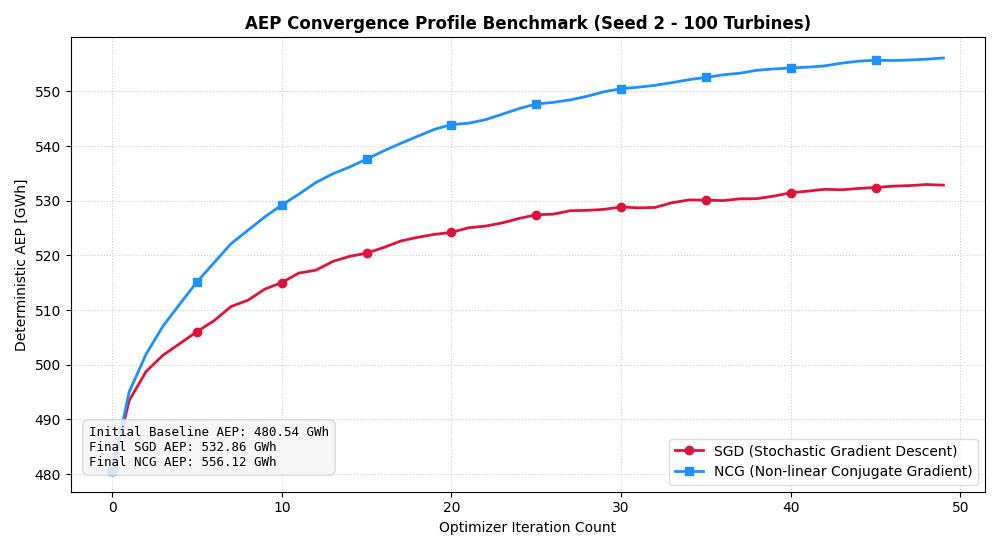

In [15]:

target_seed = 2
target_turbines = 100

# Execute comparative analysis visualization
plot_convergence_comparison(seed=target_seed, n_turbines=target_turbines)